# RAG Pipeline — PDF to Chatbot

**Stack:** OpenAI `gpt-4o-mini` + `text-embedding-3-small` | ChromaDB | 5 Chunking Strategies

---

**Strategies:** Fixed-Size Character | Recursive Character | Token-Based | Sentence-Based | Semantic

**Workflow:** `PDF -> Extract -> Chunk -> Embed -> ChromaDB -> Retrieve -> GPT-4o-mini -> Answer`

## 1. Install Dependencies

In [4]:
!pip install -q openai chromadb pypdf langchain langchain-openai langchain-community tiktoken nltk

In [7]:
!pip install -q langchain langchain-text-splitters

## 2. Imports

In [8]:
import os
import textwrap
import warnings
import numpy as np
import nltk
from typing import List, Dict, Any, Optional
import chromadb
from pypdf import PdfReader
import tiktoken
from openai import OpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
warnings.filterwarnings('ignore')
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
print('All imports loaded.')

All imports loaded.


## 3. API Key and Model Settings

In [18]:
import os
from google.colab import userdata

# Option A: Colab Secrets (recommended)
os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')

# Option B: paste directly
# os.environ['OPENAI_API_KEY'] = 'sk-...'

CHAT_MODEL  = 'gpt-4o-mini'
EMBED_MODEL = 'text-embedding-3-small'
TOP_K       = 4

client = OpenAI(api_key=os.environ['OPENAI_API_KEY'])
print(f'Chat model  : {CHAT_MODEL}')
print(f'Embed model : {EMBED_MODEL}')

Chat model  : gpt-4o-mini
Embed model : text-embedding-3-small


## 4. PDF Loader

In [10]:
from google.colab import files

print('Upload a PDF file:')
uploaded = files.upload()
PDF_PATH = list(uploaded.keys())[0]
print(f'Loaded: {PDF_PATH}')

Upload a PDF file:


Saving IIA HR Policy.pdf to IIA HR Policy.pdf
Loaded: IIA HR Policy.pdf


In [11]:
# If you prefer a fixed path, skip the upload cell and set it here:
# PDF_PATH = '/content/your_document.pdf'

def extract_text_from_pdf(pdf_path: str) -> str:
    reader = PdfReader(pdf_path)
    pages = []
    for page in reader.pages:
        text = page.extract_text()
        if text:
            pages.append(text.strip())
    full_text = '\n\n'.join(pages)
    print(f'Pages     : {len(reader.pages)}')
    print(f'Characters: {len(full_text):,}')
    return full_text


raw_text = extract_text_from_pdf(PDF_PATH)
print('\n--- First 500 characters ---')
print(raw_text[:500])

Pages     : 47
Characters: 73,865

--- First 500 characters ---
IIA HR POLICY REVISION 1.1                                                                                 1  
 
 
 
 
 
 
 
 
 
 
 
 
       Indian Industries Association 
 
Human Resource Policy

IIA HR POLICY REVISION 1.1                                                                                 2  
Preface 
Indian Industries Association (IIA) started as U.P Chapter of NAYE in 1985 was 
renamed as Indian Industries Association in 1992 and registered as a Society. Since 
then, IIA have ex


## 5. Chunking Strategies

Five strategies are implemented. After each one, the first 3 chunks are printed so you can inspect the output directly.

In [12]:
def print_chunks(chunks: List[str], strategy_name: str, n_preview: int = 3) -> None:
    sep = '-' * 70
    print(f'\n{sep}')
    print(f'  Strategy      : {strategy_name}')
    print(f'  Total chunks  : {len(chunks)}')
    avg = sum(len(c) for c in chunks) / len(chunks) if chunks else 0
    print(f'  Avg chars     : {avg:,.0f}')
    print(sep)
    for i, chunk in enumerate(chunks[:n_preview]):
        print(f'\n  [Chunk {i+1}]')
        print(textwrap.indent(chunk.strip()[:600], prefix='    '))
        if len(chunk) > 600:
            print('    ... (truncated)')
    print(sep)

### 5.1 Fixed-Size Character Chunking

In [13]:
def chunk_fixed_size(text: str, chunk_size: int = 500, overlap: int = 50) -> List[str]:
    """
    Sliding window over raw characters.
    Simple and fast but ignores sentence and paragraph boundaries.
    """
    chunks = []
    start = 0
    while start < len(text):
        end = start + chunk_size
        chunks.append(text[start:end])
        start += chunk_size - overlap
    return chunks


chunks_fixed = chunk_fixed_size(raw_text, chunk_size=500, overlap=50)
print_chunks(chunks_fixed, 'Fixed-Size Character (size=500, overlap=50)')


----------------------------------------------------------------------
  Strategy      : Fixed-Size Character (size=500, overlap=50)
  Total chunks  : 165
  Avg chars     : 497
----------------------------------------------------------------------

  [Chunk 1]
    IIA HR POLICY REVISION 1.1                                                                                 1  
 
 
 
 
 
 
 
 
 
 
 
 
           Indian Industries Association 
 
    Human Resource Policy

    IIA HR POLICY REVISION 1.1                                                                                 2  
    Preface 
    Indian Industries Association (IIA) started as U.P Chapter of NAYE in 1985 was 
    renamed as Indian Industries Association in 1992 and registered as a Society. Since 
    then, IIA have ex

  [Chunk 2]
    registered as a Society. Since 
    then, IIA have expanded its membership base and territorial boundaries not only to 
    almost all the districts of U.P but outside U.P also. As on date

### 5.2 Recursive Character Text Splitting
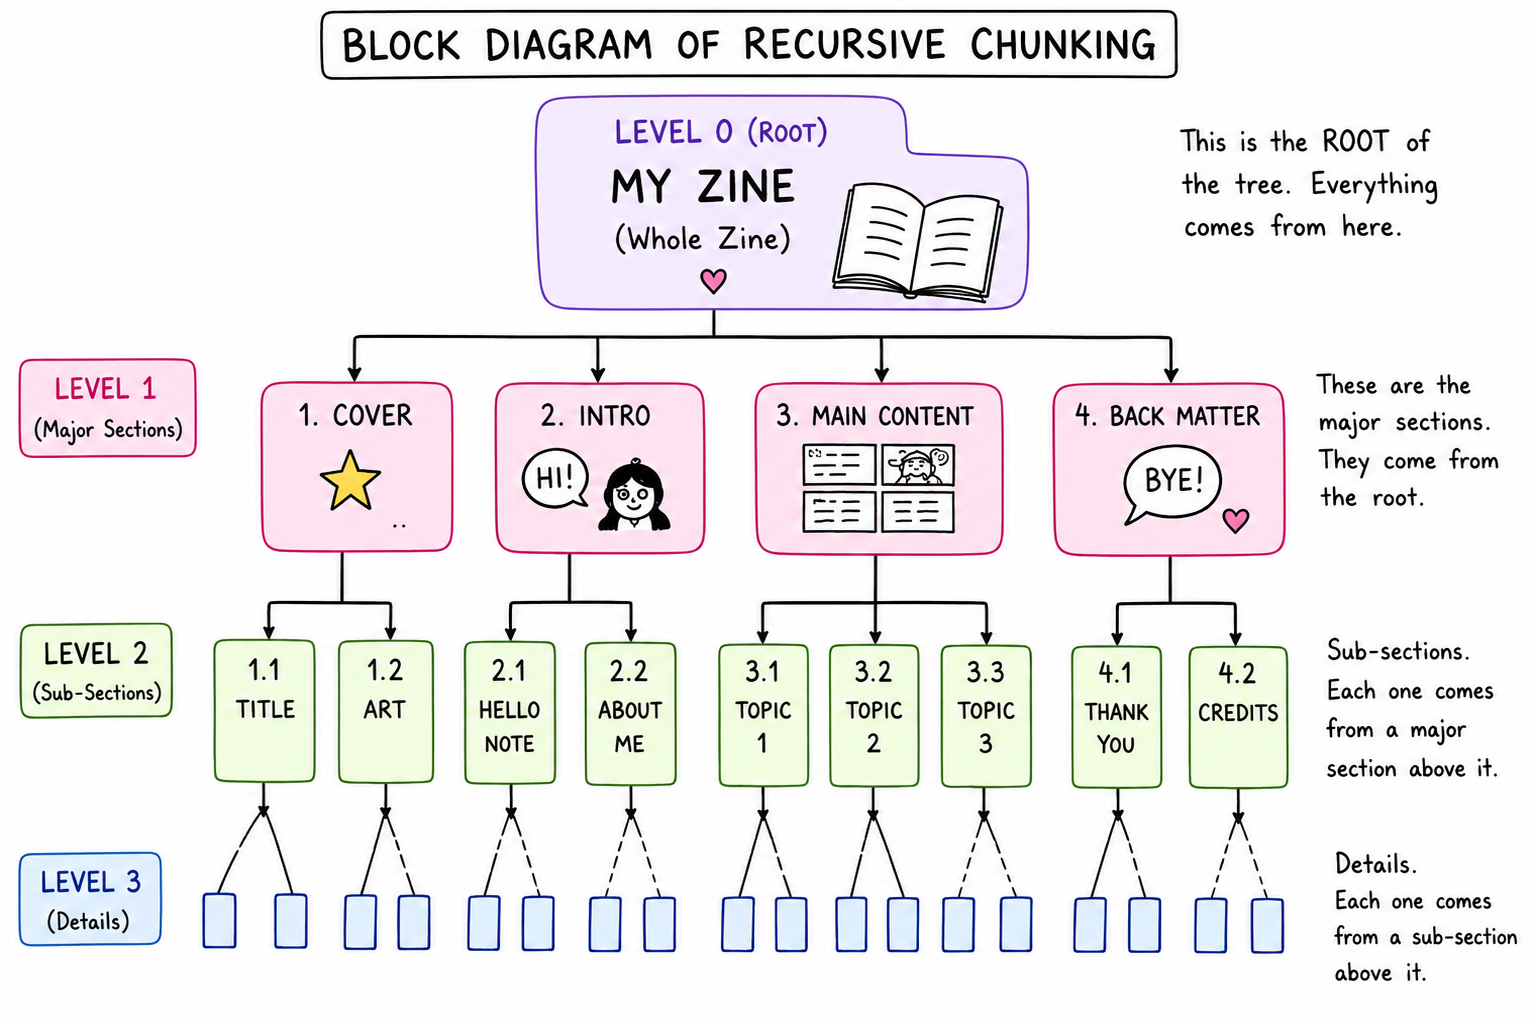

In [14]:
def chunk_recursive(text: str, chunk_size: int = 500, overlap: int = 80) -> List[str]:
    """
    LangChain RecursiveCharacterTextSplitter.
    Tries paragraph -> newline -> sentence -> word -> character in order,
    preserving natural boundaries as much as possible.
    """
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=overlap,
        separators=['\n\n', '\n', '. ', '! ', '? ', ' ', ''],
        length_function=len,
    )
    return splitter.split_text(text)


chunks_recursive = chunk_recursive(raw_text, chunk_size=500, overlap=80)
print_chunks(chunks_recursive, 'Recursive Character (size=500, overlap=80)')


----------------------------------------------------------------------
  Strategy      : Recursive Character (size=500, overlap=80)
  Total chunks  : 188
  Avg chars     : 411
----------------------------------------------------------------------

  [Chunk 1]
    IIA HR POLICY REVISION 1.1                                                                                 1  
 
 
 
 
 
 
 
 
 
 
 
 
           Indian Industries Association 
 
    Human Resource Policy

  [Chunk 2]
    IIA HR POLICY REVISION 1.1                                                                                 2  
    Preface 
    Indian Industries Association (IIA) started as U.P Chapter of NAYE in 1985 was 
    renamed as Indian Industries Association in 1992 and registered as a Society. Since 
    then, IIA have expanded its membership base and territorial boundaries not only to 
    almost all the districts of U.P but outside U.P also. As on date more than 12000

  [Chunk 3]
    members are associated wit

### 5.3 Token-Based Chunking

In [15]:
def chunk_by_tokens(
    text: str,
    max_tokens: int = 150,
    overlap_tokens: int = 20,
    encoding_name: str = 'cl100k_base',
) -> List[str]:
    """
    Split on tiktoken token boundaries instead of character counts.
    More accurate for LLM context budgets.
    cl100k_base matches GPT-4 / text-embedding-3-small.
    """
    enc = tiktoken.get_encoding(encoding_name)
    tokens = enc.encode(text)
    chunks = []
    start = 0
    while start < len(tokens):
        end = min(start + max_tokens, len(tokens))
        chunks.append(enc.decode(tokens[start:end]))
        start += max_tokens - overlap_tokens
    return chunks


chunks_token = chunk_by_tokens(raw_text, max_tokens=150, overlap_tokens=20)
print_chunks(chunks_token, 'Token-Based (max=150 tokens, overlap=20)')


----------------------------------------------------------------------
  Strategy      : Token-Based (max=150 tokens, overlap=20)
  Total chunks  : 121
  Avg chars     : 702
----------------------------------------------------------------------

  [Chunk 1]
    IIA HR POLICY REVISION 1.1                                                                                 1  
 
 
 
 
 
 
 
 
 
 
 
 
           Indian Industries Association 
 
    Human Resource Policy

    IIA HR POLICY REVISION 1.1                                                                                 2  
    Preface 
    Indian Industries Association (IIA) started as U.P Chapter of NAYE in 1985 was 
    renamed as Indian Industries Association in 1992 and registered as a Society. Since 
    then, IIA have expanded its membership base and territorial boundaries not only to 
    almost all the districts of U.P b
    ... (truncated)

  [Chunk 2]
    IIA in  various States i.e Uttar Pradesh, Uttarak hand, 
    Delhi,

### 5.4 Sentence-Based Chunking

In [16]:
def chunk_by_sentences(
    text: str,
    sentences_per_chunk: int = 5,
    overlap_sentences: int = 1,
) -> List[str]:
    """
    Tokenize into sentences using NLTK, then group N sentences per chunk.
    Chunks always end at sentence boundaries, preserving grammatical coherence.
    """
    sentences = nltk.sent_tokenize(text)
    chunks = []
    start = 0
    while start < len(sentences):
        end = min(start + sentences_per_chunk, len(sentences))
        chunks.append(' '.join(sentences[start:end]))
        start += sentences_per_chunk - overlap_sentences
    return chunks


chunks_sentence = chunk_by_sentences(raw_text, sentences_per_chunk=5, overlap_sentences=1)
print_chunks(chunks_sentence, 'Sentence-Based (5 sentences, 1 overlap)')


----------------------------------------------------------------------
  Strategy      : Sentence-Based (5 sentences, 1 overlap)
  Total chunks  : 120
  Avg chars     : 766
----------------------------------------------------------------------

  [Chunk 1]
    IIA HR POLICY REVISION 1.1                                                                                 1  
 
 
 
 
 
 
 
 
 
 
 
 
           Indian Industries Association 
 
    Human Resource Policy

    IIA HR POLICY REVISION 1.1                                                                                 2  
    Preface 
    Indian Industries Association (IIA) started as U.P Chapter of NAYE in 1985 was 
    renamed as Indian Industries Association in 1992 and registered as a Society. Since 
    then, IIA have expanded its membership base and territorial boundaries not only to 
    almost all the districts of U.P b
    ... (truncated)

  [Chunk 2]
    The execution of the policies, programmes and services of the 
    a

### 5.5 Semantic Chunking

Embeds every sentence, computes cosine similarity between adjacent sentences, and inserts a chunk boundary where similarity drops below a threshold. Produces contextually coherent chunks that respect topic shifts.

In [19]:
def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)
    if norm_a == 0 or norm_b == 0:
        return 0.0
    return float(np.dot(a, b) / (norm_a * norm_b))


def embed_texts_batch(texts: List[str], batch_size: int = 100) -> List[np.ndarray]:
    embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        response = client.embeddings.create(model=EMBED_MODEL, input=batch)
        embeddings.extend([np.array(item.embedding) for item in response.data])
    return embeddings


def chunk_semantic(
    text: str,
    similarity_threshold: float = 0.75,
    min_chunk_sentences: int = 2,
    max_chunk_sentences: int = 15,
) -> List[str]:
    """
    Semantic chunking via sentence-level embedding similarity.

    Algorithm:
      1. Tokenize text into sentences.
      2. Embed each sentence with text-embedding-3-small.
      3. Compute cosine similarity between consecutive sentence pairs.
      4. Insert a chunk boundary when similarity < threshold
         or when the chunk exceeds max_chunk_sentences.
    """
    sentences = nltk.sent_tokenize(text)
    if not sentences:
        return []

    print(f'  Embedding {len(sentences)} sentences for semantic analysis ...')
    embeddings = embed_texts_batch(sentences)

    similarities = [
        cosine_similarity(embeddings[i], embeddings[i + 1])
        for i in range(len(embeddings) - 1)
    ]

    chunks = []
    current = [sentences[0]]

    for i, sim in enumerate(similarities):
        next_sentence = sentences[i + 1]
        boundary = (
            sim < similarity_threshold
            or len(current) >= max_chunk_sentences
        )
        if boundary and len(current) >= min_chunk_sentences:
            chunks.append(' '.join(current))
            current = [next_sentence]
        else:
            current.append(next_sentence)

    if current:
        chunks.append(' '.join(current))

    return chunks


print('Running semantic chunking (one OpenAI API call per sentence batch)...')
chunks_semantic = chunk_semantic(raw_text, similarity_threshold=0.75)
print_chunks(chunks_semantic, 'Semantic (cosine similarity, threshold=0.75)')

Running semantic chunking (one OpenAI API call per sentence batch)...
  Embedding 479 sentences for semantic analysis ...

----------------------------------------------------------------------
  Strategy      : Semantic (cosine similarity, threshold=0.75)
  Total chunks  : 235
  Avg chars     : 312
----------------------------------------------------------------------

  [Chunk 1]
    IIA HR POLICY REVISION 1.1                                                                                 1  
 
 
 
 
 
 
 
 
 
 
 
 
           Indian Industries Association 
 
    Human Resource Policy

    IIA HR POLICY REVISION 1.1                                                                                 2  
    Preface 
    Indian Industries Association (IIA) started as U.P Chapter of NAYE in 1985 was 
    renamed as Indian Industries Association in 1992 and registered as a Society. Since 
    then, IIA have expanded its membership base and territorial boundaries not only to 
    almost all t

## 6. Strategy Comparison Summary

In [20]:
all_strategies = {
    'Fixed-Size Character' : chunks_fixed,
    'Recursive Character'  : chunks_recursive,
    'Token-Based'          : chunks_token,
    'Sentence-Based'       : chunks_sentence,
    'Semantic'             : chunks_semantic,
}

print(f"{'Strategy':<28} {'Chunks':>8} {'Avg Chars':>12} {'Min':>8} {'Max':>8}")
print('-' * 68)
for name, chunks in all_strategies.items():
    sizes = [len(c) for c in chunks]
    print(
        f"{name:<28} {len(chunks):>8,}"
        f" {sum(sizes)/len(sizes):>12,.0f}"
        f" {min(sizes):>8,}"
        f" {max(sizes):>8,}"
    )

Strategy                       Chunks    Avg Chars      Min      Max
--------------------------------------------------------------------
Fixed-Size Character              165          497       65      500
Recursive Character               188          411       29      498
Token-Based                       121          702      165    1,864
Sentence-Based                    120          766       58    3,814
Semantic                          235          312       20    2,251


## 7. Select Active Strategy

Change `ACTIVE_STRATEGY` to switch which chunks are indexed into ChromaDB.

In [45]:
# Options: 'Fixed-Size Character', 'Recursive Character',
#          'Token-Based', 'Sentence-Based', 'Semantic'
ACTIVE_STRATEGY = 'Recursive Character'

active_chunks = all_strategies[ACTIVE_STRATEGY]
print(f'Active strategy : {ACTIVE_STRATEGY}')
print(f'Chunks to index : {len(active_chunks)}')

Active strategy : Recursive Character
Chunks to index : 188


## 8. ChromaDB — Embed and Index

In [37]:
class OpenAIEmbeddingFunction:
    """
    ChromaDB-compatible embedding function backed by text-embedding-3-small.
    ChromaDB calls this with a list of texts and expects a list of float vectors.
    """
    def __init__(self, model: str = EMBED_MODEL):
        self.model = model

    def __call__(self, input: List[str]) -> List[List[float]]:
        response = client.embeddings.create(model=self.model, input=input)
        return [item.embedding for item in response.data]

    def embed_query(self, input: str) -> List[List[float]]:
        # ChromaDB expects a list of embedding vectors for `query_embeddings`.
        # For a single query, we return a list containing one embedding vector.
        response = client.embeddings.create(model=self.model, input=input)
        return [response.data[0].embedding]


embedding_fn = OpenAIEmbeddingFunction()

# In-memory ChromaDB (resets on runtime restart)
chroma_client = chromadb.Client()

# Persistent ChromaDB (survives restarts)
# chroma_client = chromadb.PersistentClient(path='/content/chroma_db')

COLLECTION_NAME = 'rag_collection'

try:
    chroma_client.delete_collection(COLLECTION_NAME)
except Exception:
    pass

collection = chroma_client.create_collection(
    name=COLLECTION_NAME,
    embedding_function=embedding_fn,
    metadata={'hnsw:space': 'cosine'},
)
print(f"Collection '{COLLECTION_NAME}' created.")

Collection 'rag_collection' created.


In [38]:
def index_chunks(
    collection,
    chunks: List[str],
    strategy_name: str,
    batch_size: int = 50,
) -> None:
    total = len(chunks)
    for i in range(0, total, batch_size):
        batch = chunks[i : i + batch_size]
        ids = [f"{strategy_name.replace(' ', '_')}_{i+j}" for j in range(len(batch))]
        metadatas = [
            {'chunk_index': i + j, 'strategy': strategy_name, 'char_count': len(c)}
            for j, c in enumerate(batch)
        ]
        collection.upsert(documents=batch, ids=ids, metadatas=metadatas)
        print(f'  Indexed {min(i + batch_size, total):>5} / {total}', end='\r')
    print(f'  Indexed {total} / {total} -- done.          ')


print(f'Indexing with strategy: {ACTIVE_STRATEGY}')
index_chunks(collection, active_chunks, ACTIVE_STRATEGY)
print(f'Collection size: {collection.count()} documents')

Indexing with strategy: Recursive Character
  Indexed 188 / 188 -- done.          
Collection size: 188 documents


## 9. Retriever

In [46]:
def retrieve(
    query: str,
    top_k: int = TOP_K,
    verbose: bool = True,
) -> List[Dict[str, Any]]:
    """
    Retrieve top-K most relevant chunks from ChromaDB.
    When verbose=True, prints each chunk with rank and similarity score
    so you can inspect what the model will use before the answer is generated.
    """
    results = collection.query(
        query_texts=[query],
        n_results=top_k,
        include=['documents', 'metadatas', 'distances'],
    )

    retrieved = []
    for doc, meta, dist in zip(
        results['documents'][0],
        results['metadatas'][0],
        results['distances'][0],
    ):
        retrieved.append({
            'text'        : doc,
            'chunk_index' : meta.get('chunk_index'),
            'strategy'    : meta.get('strategy'),
            'similarity'  : round(1 - dist, 4),
        })

    if verbose:
        sep = '=' * 70
        print(f'\n{sep}')
        print(f'  Query     : {query}')
        print(f'  Retrieved : {len(retrieved)} chunks')
        print(sep)
        for rank, r in enumerate(retrieved, 1):
            print(f"\n  [Rank {rank}] Chunk #{r['chunk_index']} | Similarity: {r['similarity']}")
            print(textwrap.indent(r['text'].strip()[:600], prefix='    '))
            if len(r['text']) > 600:
                print('    ... (truncated)')
        print(sep)

    return retrieved


# Sanity-check retrieval
_ = retrieve('What is the main topic of this document?', top_k=TOP_K)


  Query     : What is the main topic of this document?
  Retrieved : 4 chunks

  [Rank 1] Chunk #20 | Similarity: 0.3833
    It focuses on employees to have clear expectations on work requirements, 
    compensation, welfare and career development, sets clear and specific standards, 
    procedure and a framework to spot and address deviations and violations of these 
    standards. As a documented record, it rules out ambiguity and scope for subjective 
    and open interpretations.

  [Rank 2] Chunk #23 | Similarity: 0.3634
    It is a detailed 
    layout of format for best practices in human resource development. It enables clarity 
    and norming of practices on various issues related to HR management.

  [Rank 3] Chunk #28 | Similarity: 0.3556
    ✓ To help in documenting and communicating to all the employees the management’s 
    plans, rules, intents and business procedures. ✓ To prevent small legal issues from becoming serious legal problems.

  [Rank 4] Chunk #6 | Similari

## 10. RAG Answer Generator

In [47]:
SYSTEM_PROMPT = (
    'You are a precise, professional assistant that answers questions solely '
    'based on the provided document excerpts (context). Rules:\n'
    '1. Only use information present in the provided context.\n'
    '2. If the context does not contain enough information, say so explicitly.\n'
    '3. Do not speculate or add general knowledge.\n'
    '4. Be concise and direct.\n'
    '5. Cite which chunk your answer draws from using [Chunk #N].'
)


def build_context_block(chunks: List[Dict[str, Any]]) -> str:
    lines = []
    for r in chunks:
        lines.append(f"[Chunk #{r['chunk_index']}]\n{r['text'].strip()}")
    return '\n\n---\n\n'.join(lines)


def ask(
    query: str,
    chat_history: Optional[List[Dict[str, str]]] = None,
    top_k: int = TOP_K,
    show_chunks: bool = True,
) -> str:
    """
    Full RAG pipeline:
      1. Retrieve relevant chunks (prints them when show_chunks=True).
      2. Build a numbered context block for the prompt.
      3. Call GPT-4o-mini and return the answer.
    """
    retrieved = retrieve(query, top_k=top_k, verbose=show_chunks)

    context = build_context_block(retrieved)
    user_message = (
        f'Document context:\n\n{context}\n\n'
        f'---\n\nQuestion: {query}'
    )

    messages = [{'role': 'system', 'content': SYSTEM_PROMPT}]
    if chat_history:
        messages.extend(chat_history)
    messages.append({'role': 'user', 'content': user_message})

    response = client.chat.completions.create(
        model=CHAT_MODEL,
        messages=messages,
        temperature=0.2,
    )
    return response.choices[0].message.content.strip()


print('RAG generator ready.')

RAG generator ready.


## 11. Single Question with Chunk Inspection

In [54]:
question = 'What are the key findings discussed in this document?'

answer = ask(question, show_chunks=True)

print('\n' + '=' * 70)
print('  ANSWER')
print('=' * 70)
print(answer)
print('=' * 70)


  Query     : What are the key findings discussed in this document?
  Retrieved : 4 chunks

  [Rank 1] Chunk #6 | Similarity: 0.389
    1. Importance of HR policy 4 
    2.

  [Rank 2] Chunk #20 | Similarity: 0.3572
    It focuses on employees to have clear expectations on work requirements, 
    compensation, welfare and career development, sets clear and specific standards, 
    procedure and a framework to spot and address deviations and violations of these 
    standards. As a documented record, it rules out ambiguity and scope for subjective 
    and open interpretations.

  [Rank 3] Chunk #23 | Similarity: 0.355
    It is a detailed 
    layout of format for best practices in human resource development. It enables clarity 
    and norming of practices on various issues related to HR management.

  [Rank 4] Chunk #7 | Similarity: 0.3407
    Objectives 5 
    3. Recruitments & Selection Policy 5 
    4.

  ANSWER
The key findings discussed in the document include the importance of

## 12. Interactive Multi-Turn Chatbot

Maintains full conversation history across turns. Retrieved chunks are printed before every answer. Type `exit` or `quit` to end the session.

In [ ]:
def run_chatbot(show_chunks: bool = True) -> None:
    chat_history: List[Dict[str, str]] = []

    print('=' * 70)
    print('  RAG Chatbot')
    print(f'  Strategy : {ACTIVE_STRATEGY}')
    print(f'  Model    : {CHAT_MODEL}')
    print("  Type 'exit' or 'quit' to end the session.")
    print('=' * 70)

    while True:
        try:
            user_input = input('\nYou: ').strip()
        except (KeyboardInterrupt, EOFError):
            print('\nSession ended.')
            break

        if not user_input:
            continue
        if user_input.lower() in {'exit', 'quit'}:
            print('Session ended.')
            break

        answer = ask(
            query=user_input,
            chat_history=chat_history,
            show_chunks=show_chunks,
        )

        chat_history.append({'role': 'user', 'content': user_input})
        chat_history.append({'role': 'assistant', 'content': answer})

        print('\n' + '-' * 70)
        print('Assistant:', answer)
        print('-' * 70)


run_chatbot(show_chunks=True)

## 13. Switch Strategy and Re-Index

Run this cell to swap chunking strategies without reloading the PDF.

In [53]:
# Options: 'Fixed-Size Character', 'Recursive Character',
#          'Token-Based', 'Sentence-Based', 'Semantic'
ACTIVE_STRATEGY = 'Semantic'

active_chunks = all_strategies[ACTIVE_STRATEGY]

try:
    chroma_client.delete_collection(COLLECTION_NAME)
except Exception:
    pass

collection = chroma_client.create_collection(
    name=COLLECTION_NAME,
    embedding_function=embedding_fn,
    metadata={'hnsw:space': 'cosine'},
)

print(f'Re-indexing with strategy: {ACTIVE_STRATEGY}')
index_chunks(collection, active_chunks, ACTIVE_STRATEGY)
print(f'Collection size: {collection.count()} documents')
print('\nRe-run Section 11 or 12 to query with the new strategy.')

Re-indexing with strategy: Semantic
  Indexed 235 / 235 -- done.          
Collection size: 235 documents

Re-run Section 11 or 12 to query with the new strategy.


## Notes

| Strategy | Best For | Trade-off |
|---|---|---|
| Fixed-Size Character | Quick prototyping | Cuts mid-sentence; poor coherence |
| Recursive Character | General-purpose RAG | Good balance of speed and quality |
| Token-Based | Tight token budgets | More accurate LLM context fit |
| Sentence-Based | Narrative documents | Chunks vary widely in size |
| Semantic | Topic-shift heavy documents | Most API calls; highest coherence |

**Retrieval:** ChromaDB cosine similarity on `text-embedding-3-small` vectors (1536-dim, HNSW index).

**Generation:** `gpt-4o-mini` temperature 0.2 for factual, low-variance answers.

**Chunk visibility:** Retrieved chunks are printed before every answer so you can audit exactly what the model is using.